In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

442
ARIMA 732
Prophet 732
TimeSeers 732
Vangja hierarchical 732
Vangja from posterior 732
Vangja combined 732
ETS 732
UC 732


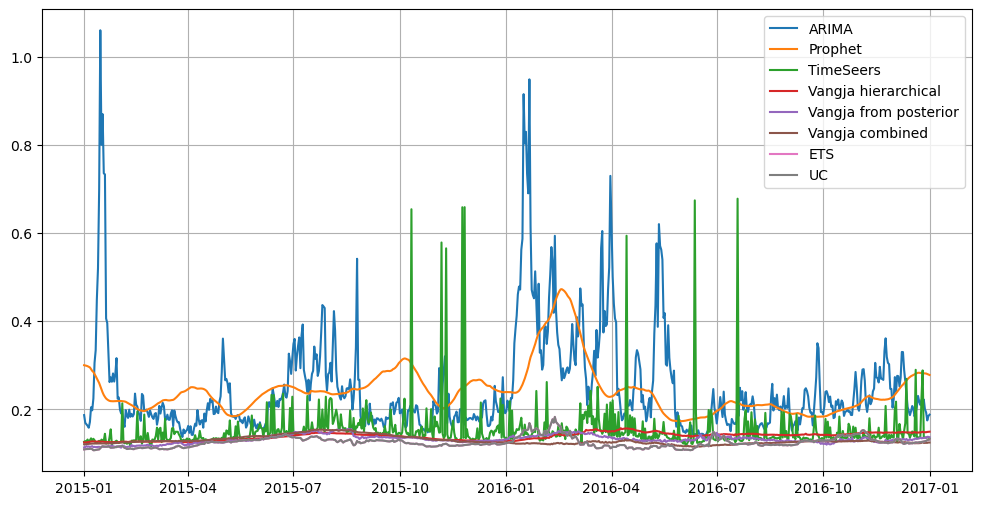

In [11]:
parent_path = Path("./") / "out"

paths = [
    parent_path / "arima",
    parent_path / "prophet" / "test2",
    parent_path / "timeseers" / "model_4",
    parent_path / "h_prophet_1" / "model_6",
    parent_path / "vangja2" / "model_5",
    parent_path / "h_vangja_tune_delta_complete" / "model_3",
    parent_path / "es",
    parent_path / "uc",
]
labels = [
    "ARIMA",
    "Prophet",
    "TimeSeers",
    "Vangja hierarchical",
    "Vangja from posterior",
    "Vangja combined",
    "ETS",
    "UC",
]
index = None

for point in pd.date_range("2015-01-01", "2017-01-01"):
    point_str = f"{point.year}-{'' if point.month > 9 else '0'}{point.month}-{'' if point.day > 9 else '0'}{point.day}"
    model_name = f"{point_str}"
    csv_path = paths[0] / f"{model_name}.csv"
    vangja_path = paths[4] / f"{point_str}.csv"
    if not csv_path.is_file() or not vangja_path.is_file():
        print(csv_path, vangja_path)
        continue

    index_1 = pd.read_csv(csv_path, index_col=0).index
    index_2 = pd.read_csv(vangja_path, index_col=0).index
    index_1 = index_1.intersection(index_2)
    if index is None:
        index = index_1

    index = index.intersection(index_1)

print(len(index))
plt.figure(figsize=(12, 6))

for idx, (path, label) in enumerate(zip(paths, labels)):
    dates = []
    mapes = []
    for point in pd.date_range("2015-01-01", "2017-01-01"):
        point_str = f"{point.year}-{'' if point.month > 9 else '0'}{point.month}-{'' if point.day > 9 else '0'}{point.day}"
        csv_path = (
            path / f"prophet_{point_str}_multiplicative_lt0_w.csv"
            if idx == 1
            else path / f"{point_str}.csv"
        )

        if not csv_path.is_file():
            continue

        dates.append(point)
        mapes.append(pd.read_csv(csv_path, index_col=0)["mape"].mean())

    print(label, len(dates))
    # plt.plot(dates, mapes, label=f"{label} ~ {100 * sum(mapes) / len(mapes):.2f}")
    plt.plot(dates, mapes, label=label)

plt.grid()
plt.legend()